In [15]:
%load_ext autoreload
%autoreload 2
import sys
import os
import copy
import pandas as pd

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.plotting_style import set_figure_size


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def parse_finetuned_cell(cell):
    """
    Parses a string of the form:
    '0.93(0.91)/0.75(0.81)[0.71]' into:
    Jigsaw_Macro, Jigsaw_True, Task_Macro, Task_True, Certified_Macro
    """
    try:
        jigsaw_part, rest = cell.split("/")
        jigsaw_macro = float(jigsaw_part.split("(")[0])
        jigsaw_true = float(jigsaw_part.split("(")[1].rstrip(")"))

        task_part, certified_part = rest.split("[")
        task_macro = float(task_part.split("(")[0])
        task_true = float(task_part.split("(")[1].rstrip(")"))

        certified_macro = float(certified_part.rstrip("]"))
        return pd.Series(
            [jigsaw_macro, jigsaw_true, task_macro, task_true, certified_macro]
        )
    except Exception as e:
        print(f"Error parsing cell: {cell} -> {e}")
        return pd.Series([None] * 5)


def get_multilang_data():
    """
    Returns a DataFrame with multilingual fine-tuning results.
    The DataFrame contains the model names and their corresponding scores
    for various languages.
    """
    # --- Define your fine-tuned results ---
    finetuned_data = {
        "Model": [
            "mxbai-embed-large-v1",
            "gte-large",
            "voyage-3",
            "gemini",
            "text-embedding-3-large",
        ],
        "arabic": [
            "0.84(0.82)/0.51(0.64)[0.73]",
            "0.82(0.79)/0.51(0.61)[0.71]",
            "0.84(0.82)/0.8(0.82)[0.7]",
            "0.83(0.81)/0.5(0.66)[0.69]",
            "0.89(0.89)/0.84(0.85)[0.73]",
        ],
        "german": [
            "0.85(0.83)/0.65(0.66)[0.74]",
            "0.81(0.81)/0.64(0.69)[0.72]",
            "0.83(0.81)/0.74(0.75)[0.7]",
            "0.85(0.84)/0.76(0.76)[0.69]",
            "0.88(0.89)/0.82(0.83)[0.75]",
        ],
        "hindi": [
            "0.83(0.82)/0.61(0.64)[0.74]",
            "0.83(0.81)/0.61(0.66)[0.72]",
            "0.84(0.82)/0.65(0.68)[0.75]",
            "0.84(0.81)/0.58(0.62)[0.69]",
            "0.89(0.89)/0.63(0.67)[0.8]",
        ],
        "portuguese": [
            "0.84(0.83)/0.53(0.66)[0.73]",
            "0.82(0.8)/0.52(0.67)[0.71]",
            "0.83(0.81)/0.74(0.79)[0.7]",
            "0.84(0.82)/0.69(0.73)[0.72]",
            "0.89(0.89)/0.85(0.86)[0.74]",
        ],
        "italian": [
            "0.84(0.82)/0.68(0.72)[0.73]",
            "0.82(0.8)/0.65(0.71)[0.71]",
            "0.83(0.82)/0.82(0.83)[0.7]",
            "0.85(0.83)/0.77(0.78)[0.69]",
            "0.88(0.89)/0.84(0.85)[0.87]",
        ],
        "spanish": [
            "0.84(0.82)/0.61(0.66)[0.73]",
            "0.82(0.8)/0.62(0.68)[0.71]",
            "0.84(0.82)/0.73(0.75)[0.71]",
            "0.85(0.83)/0.73(0.75)[0.72]",
            "0.89(0.88)/0.77(0.8)[0.74]",
        ],
        "french": [
            "0.84(0.83)/0.73(0.76)[0.73]",
            "0.82(0.81)/0.72(0.77)[0.72]",
            "0.83(0.82)/0.79(0.81)[0.7]",
            "0.85(0.84)/0.8(0.81)[0.69]",
            "0.89(0.89)/0.8(0.83)[0.73]",
        ],
    }

    # --- Convert to DataFrame ---
    finetuned_df = pd.DataFrame(finetuned_data)

    # --- Reshape to long format ---
    finetuned_long = finetuned_df.melt(
        id_vars="Model", var_name="Dataset", value_name="Finetuned_Score"
    )
    # --- Apply parsing function ---
    finetuned_long[
        ["Jigsaw_Macro", "Jigsaw_True", "Task_Macro", "Task_True", "Certified_Macro"]
    ] = finetuned_long["Finetuned_Score"].apply(parse_finetuned_cell)

    # --- Drop the raw string column ---
    finetuned_long.drop(columns="Finetuned_Score", inplace=True)

    # `finetuned_long` is now ready for analysis or plotting
    display(finetuned_long.head())

    return finetuned_long


def get_hate_data():
    # --- Define your fine-tuned results ---
    finetuned_data = {
        "Model": [
            "text-embedding-3-large",
            "mxbai-embed-large-v1",
            "m2-bert-80M-2k-retrieval",
            "gte-large",
            "voyage-3",
        ],
        "tweets_hate_speech_detection": [
            "0.94(0.92)/0.72(0.83)[0.81]",
            "0.92(0.91)/0.69(0.75)[0.74]",
            "0.84(0.85)/0.64(0.58)[0.73]",
            "0.91(0.89)/0.69(0.73)[0.75]",
            "0.88(0.89)/0.73(0.69)[0.74]",
        ],
        "civil_comments": [
            "0.94(0.93)/0.82(0.82)[0.86]",
            "0.92(0.92)/0.8(0.82)[0.77]",
            "0.84(0.85)/0.71(0.69)[0.72]",
            "0.91(0.9)/0.78(0.79)[0.74]",
            "0.88(0.89)/0.74(0.7)[0.77]",
        ],
        "hatemoji": [
            "0.93(0.94)/0.74(0.8)[0.77]",
            "0.92(0.93)/0.58(0.61)[0.75]",
            "0.84(0.85)/0.57(0.61)[0.73]",
            "0.91(0.91)/0.53(0.65)[0.89]",
            "0.88(0.88)/0.56(0.68)[0.86]",
        ],
        "sbic": [
            "0.94(0.93)/0.71(0.71)[0.77]",
            "0.92(0.91)/0.64(0.65)[0.77]",
            "0.83(0.86)/0.66(0.65)[0.72]",
            "0.91(0.87)/0.64(0.64)[0.74]",
            "0.88(0.88)/0.65(0.65)[0.74]",
        ],
        "hatecheck": [
            "0.93(0.95)/0.7(0.8)[0.77]",
            "0.91(0.95)/0.62(0.68)[0.77]",
            "0.83(0.87)/0.57(0.64)[0.72]",
            "0.87(0.95)/0.62(0.7)[0.74]",
            "0.87(0.91)/0.6(0.73)[0.74]",
        ],
    }

    # --- Convert to DataFrame ---
    finetuned_df = pd.DataFrame(finetuned_data)

    # --- Reshape to long format ---
    finetuned_long = finetuned_df.melt(
        id_vars="Model", var_name="Dataset", value_name="Finetuned_Score"
    )

    # --- Apply parsing function ---
    finetuned_long[
        ["Jigsaw_Macro", "Jigsaw_True", "Task_Macro", "Task_True", "Certified_Macro"]
    ] = finetuned_long["Finetuned_Score"].apply(parse_finetuned_cell)

    # --- Drop the raw string column ---
    finetuned_long.drop(columns="Finetuned_Score", inplace=True)

    # `finetuned_long` is now ready for analysis or plotting
    display(finetuned_long.head())
    return finetuned_long


hate_data = get_hate_data()
multi_lang_data = get_multilang_data()


,Model,Dataset,Jigsaw_Macro,Jigsaw_True,Task_Macro,Task_True,Certified_Macro
0,text-embedding-3-large,tweets_hate_speech_detection,0.94,0.92,0.72,0.83,0.81
1,mxbai-embed-large-v1,tweets_hate_speech_detection,0.92,0.91,0.69,0.75,0.74
2,m2-bert-80M-2k-retrieval,tweets_hate_speech_detection,0.84,0.85,0.64,0.58,0.73
3,gte-large,tweets_hate_speech_detection,0.91,0.89,0.69,0.73,0.75
4,voyage-3,tweets_hate_speech_detection,0.88,0.89,0.73,0.69,0.74


,Model,Dataset,Jigsaw_Macro,Jigsaw_True,Task_Macro,Task_True,Certified_Macro
0,mxbai-embed-large-v1,arabic,0.84,0.82,0.51,0.64,0.73
1,gte-large,arabic,0.82,0.79,0.51,0.61,0.71
2,voyage-3,arabic,0.84,0.82,0.80,0.82,0.70
3,gemini,arabic,0.83,0.81,0.50,0.66,0.69
4,text-embedding-3-large,arabic,0.89,0.89,0.84,0.85,0.73


In [58]:
DATASETS_TO_PLOT = [
    "civil_comments",
    "hatecheck",
    "hatemoji",
    "german",
    "italian",
    "french",
]

TITLES = {
    "arabic": "Arabic",
    "english": "English",
    "spanish": "Spanish",
    "portuguese": "Portuguese",
    "german": "German",
    "hindi": "Hindi",
    "french": "French",
    "italian": "Italian",
    "tweets_hate_speech_detection": "Twitter\nHate Speech",
    "civil_comments": "Civil Comments",
    "hatemoji": "Hatemoji",
    "sbic": "Sbic",
    "hatecheck": "Hatecheck",
}

MODEL_NAMES = {
    "text-embedding-3-large": "3-large (OpenAI)",
    "mxbai-embed-large-v1": "MXBAI (Mistral)",
    "gemini": "Gemini (Google)",
    "gte-large": "GTE-Large (Alibaba)",
    "voyage-3": "Voyage AI",
    "m2-bert-80M-2k-retrieval": "M2-BERT (Together)",
}

MODEL_COLORS = {
    "text-embedding-3-large": "C0",
    "mxbai-embed-large-v1": "C1",
    "gemini": "C2",
    "gte-large": "C3",
    "voyage-3": "C4",
    "m2-bert-80M-2k-retrieval": "C5",
}

In [89]:
def plot_multilang_results(finetuned_long, fig, axs):
    """
    Plots the multilingual fine-tuning results.
    """
    # Use the cleaned finetuned DataFrame
    models = finetuned_long["Model"].unique()
    datasets = list(finetuned_long["Dataset"].unique())  # order preserved
    print(datasets)

    # Provide Jigsaw baseline macro accuracy separately for plotting stars
    baseline_jigsaw_macro = {
        "mxbai-embed-large-v1": 0.85,
        "gte-large": 0.83,
        "voyage-3": 0.84,
        "gemini": 0.84,
        "text-embedding-3-large": 0.88,
    }

    # Define baseline macro accuracy per model *per dataset*
    # (from the baseline results table in your first message)
    baseline_macro_lookup = {
        ("voyage-3", "german"): 0.7344,
        ("voyage-3", "french"): 0.8321,
        ("voyage-3", "italian"): 0.8089,
    }

    axs = iter(axs)

    for dataset in datasets:
        if dataset not in DATASETS_TO_PLOT:
            continue
        ax = next(axs)

        macro_scores = [
            baseline_macro_lookup[(model, dataset)]
            for model in models
            if (model, dataset) in baseline_macro_lookup
        ]
        min_baseline_macro = np.min(macro_scores)
        ax.axhline(
            min_baseline_macro,
            linestyle="--",
            color="gray",
            label="Min Baseline Acc. (Task 2)",
        )

        for model in models:
            color = MODEL_COLORS[model]
            row = finetuned_long[
                (finetuned_long["Model"] == model)
                & (finetuned_long["Dataset"] == dataset)
            ]
            row = row.iloc[0]
            baseline_macro = baseline_jigsaw_macro[model]
            # Line connecting baseline, finetuned, certified
            x_vals = [baseline_macro, row["Jigsaw_Macro"], row["Certified_Macro"]]
            y_vals = [row["Task_Macro"]] * 3
            ax.plot(x_vals, y_vals, color=color, linestyle="-", marker="none")

            # Markers
            ax.plot(
                row["Jigsaw_Macro"],
                row["Task_Macro"],
                color=color,
                marker="o",
                markersize=3,
                markeredgewidth=0.5,
                markerfacecolor="none",
            )  # finetuned
            ax.plot(
                baseline_macro,
                row["Task_Macro"],
                color=color,
                marker="*",
                markersize=5,
                markeredgewidth=0.0,
            )  # baseline
            ax.plot(
                row["Certified_Macro"],
                row["Task_Macro"],
                color=color,
                marker="|",
                markersize=5,
            )  # certified - hollow circle with thinner edge

        # Title and axes
        ax.set_title(TITLES[dataset], y=1.01, va="center", fontsize=8)
        ax.set_xlim(0.45, 1.05)
        ax.set_xticks([0.5, 0.75, 1.0], labels=["0.5", "", "1.0"])
        ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
        ax.grid(True, linestyle="--", alpha=0.6)

In [86]:
def plot_hate_results(finetuned_long, fig, axs):
    # Define baseline macro accuracy per model *per dataset*
    # (from the baseline results table in your first message)
    baseline_macro_lookup = {
        ("m2-bert-80M-2k-retrieval", "tweets_hate_speech_detection"): 0.7706,
        ("m2-bert-80M-2k-retrieval", "civil_comments"): 0.7264,
        ("m2-bert-80M-2k-retrieval", "hatemoji"): 0.5922,
        ("m2-bert-80M-2k-retrieval", "sbic"): 0.7401,
        ("m2-bert-80M-2k-retrieval", "hatecheck"): 0.6656,
    }

    # Baseline Jigsaw macro per model (for plotting the star)
    baseline_jigsaw_macro = {
        "text-embedding-3-large": 0.94,
        "mxbai-embed-large-v1": 0.92,
        "m2-bert-80M-2k-retrieval": 0.86,
        "gte-large": 0.90,
        "voyage-3": 0.90,
    }
    # Use the cleaned finetuned DataFrame
    models = finetuned_long["Model"].unique()
    datasets = list(finetuned_long["Dataset"].unique())  # order preserved
    print(datasets)

    axs = iter(axs)

    for dataset in datasets:
        if dataset not in DATASETS_TO_PLOT:
            continue
        ax = next(axs)

        macro_scores = [
            baseline_macro_lookup[(model, dataset)]
            for model in models
            if (model, dataset) in baseline_macro_lookup
        ]
        min_baseline_macro = np.min(macro_scores)
        ax.axhline(
            min_baseline_macro,
            linestyle="--",
            color="gray",
            label="Min Baseline Acc. (Task 2)",
        )

        for model in models:
            row = finetuned_long[
                (finetuned_long["Model"] == model)
                & (finetuned_long["Dataset"] == dataset)
            ]

            row = row.iloc[0]
            baseline_macro = baseline_jigsaw_macro[model]

            # Line connecting baseline, finetuned, certified
            x_vals = [baseline_macro, row["Jigsaw_Macro"], row["Certified_Macro"]]
            y_vals = [row["Task_Macro"]] * 3
            ax.plot(
                x_vals, y_vals, color=MODEL_COLORS[model], linestyle="-", marker="none"
            )

            # Markers
            ax.plot(
                row["Jigsaw_Macro"],
                row["Task_Macro"],
                color=MODEL_COLORS[model],
                marker="o",
                markersize=3,
                markeredgewidth=0.5,
                markerfacecolor="none",
            )  # finetuned
            ax.plot(
                baseline_macro,
                row["Task_Macro"],
                color=MODEL_COLORS[model],
                marker="*",
                markersize=5,
                markeredgewidth=0.0,
            )  # baseline
            ax.plot(
                row["Certified_Macro"],
                row["Task_Macro"],
                color=MODEL_COLORS[model],
                marker="|",
                markersize=5,
            )  # certified - hollow circle with thinner edge

        # Title and axes
        ax.set_title(TITLES[dataset], y=1.01, va="center", fontsize=8)
        ax.set_xlim(0.45, 1.05)
        ax.set_xticks([0.5, 0.75, 1.0], labels=["0.5", "", "1.0"])
        ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
        ax.grid(True, linestyle="--", alpha=0.6)


In [87]:
def create_legend_handles():
    """
    Creates legend handles for the plot.
    """
    # Top row: model-color legend (simplified labels)
    model_lines = []
    for model in MODEL_COLORS.keys():
        # Create a legend entry for each model
        model_lines.append(
            mlines.Line2D(
                [0],
                [0],
                color=MODEL_COLORS[model],
                lw=0,
                marker="s",
                markersize=5,
                label=MODEL_NAMES[model],
            )
        )

    symbol_lines = [
        mlines.Line2D(
            [0],
            [0],
            marker="*",
            lw=0,
            color="black",
            markersize=5,
            markeredgewidth=0.0,
            label="Pre-Finetuning Acc.",
        ),
        mlines.Line2D(
            [0],
            [0],
            marker="o",
            markersize=3,
            lw=0,
            color="black",
            markeredgewidth=0.5,
            markerfacecolor="none",
            label="Post-Finetuning Acc.",
        ),
        mlines.Line2D(
            [0],
            [0],
            marker="|",
            lw=0,
            color="black",
            markersize=5,
            label="Task 1 Certificate",
        ),
        mlines.Line2D([0], [0], linestyle="--", color="gray", label="Task 2 Baseline"),
    ]

    return model_lines, symbol_lines

['tweets_hate_speech_detection', 'civil_comments', 'hatemoji', 'sbic', 'hatecheck']
['arabic', 'german', 'hindi', 'portuguese', 'italian', 'spanish', 'french']


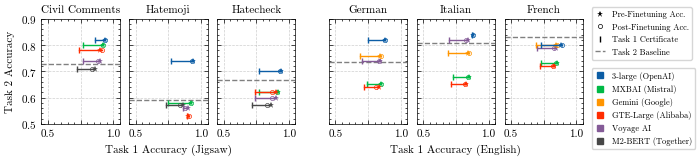

In [92]:
def plot_results_combined(hate_data, multi_lang_data):
    """
    Plots the combined results for hate speech and multilingual fine-tuning.
    """

    # Plot for each dataset
    fig, axs = plt.subplots(
        1,
        7,
        sharey=True,
        layout="constrained",
        gridspec_kw={"hspace": 0.0},
        width_ratios=[1, 1, 1, 0.2, 1, 1, 1],
    )
    axs[3].axis("off")

    # Plot hate speech results
    plot_hate_results(hate_data, fig, axs[0:3])

    # Plot multilingual results
    plot_multilang_results(multi_lang_data, fig, axs[4:7])

    model_lines, symbol_lines = create_legend_handles()

    fig.legend(
        handles=symbol_lines,
        loc="lower left",
        bbox_to_anchor=(1.0, 0.6),  # position above the plot
        ncol=1,
        frameon=True,  # outline box
        handlelength=1.2,
        fontsize=6,
    )

    fig.legend(
        handles=model_lines,
        loc="upper left",
        bbox_to_anchor=(1.0, 0.6),  # position above the plot
        ncol=1,
        frameon=True,  # outline box
        fontsize=6,
        handlelength=1.2,
    )

    axs[0].set_ylabel("Task 2 Accuracy", fontsize=8)
    axs[1].set_xlabel("Task 1 Accuracy (Jigsaw)", fontsize=8)
    axs[5].set_xlabel("Task 1 Accuracy (English)", fontsize=8)

    set_figure_size(
        fig,
        fraction=1.0,
        subplots=(1, 6),
        dpi=300,
        shrink_height=0.85,
        portrait=True,
    )

    plt.savefig("figures/combined_results.pdf", dpi=300)


plot_results_combined(hate_data, multi_lang_data)